In [1]:
!pip install yfinance numpy pandas torch pennylane scikit-learn matplotlib

In [2]:
import pandas_datareader.data as web
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
import datetime

In [3]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)
    all_stocks = pd.concat([all_stocks, tmp_close], axis=1)

#all_stocks.columns=symbols
all_stocks

YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,MMM,MMM,MMM,MMM,MMM,IBM,IBM,IBM,IBM,IBM,...,WBA,WBA,WBA,WBA,WBA,DIS,DIS,DIS,DIS,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,123.183632,124.375206,122.958004,123.606669,1677988,98.867790,100.277692,98.582639,99.089572,3781499,...,31.486053,31.994149,31.200249,31.501932,4714500,176.677399,177.724461,172.913894,173.605349,13145400
2020-12-29,122.577217,123.839303,122.083667,123.775842,1457804,98.059875,99.390574,97.616305,99.287603,3647402,...,31.287582,32.025909,31.152621,31.605143,4004400,175.136444,178.001050,174.069621,177.813366,6875400
2020-12-30,122.760559,123.331673,122.245855,122.598393,1697244,98.487587,98.891549,97.925205,98.059864,3535794,...,31.232008,31.541628,31.120863,31.374910,4194300,178.959198,181.161981,176.193363,176.321782,11680400
2020-12-31,123.240013,123.296410,122.104837,122.767604,2202195,99.707397,99.826209,98.210360,98.392540,3738822,...,31.660713,31.755980,30.985897,31.224069,7696000,178.969070,181.161981,178.070187,179.008591,7073500
2021-01-04,121.181175,124.234153,120.250473,123.388066,3583455,98.170769,99.739090,97.457894,99.683647,5417443,...,32.867432,32.994455,31.708336,31.890933,9101800,175.511780,180.361867,172.597781,180.035892,13426600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,124.913826,128.734973,124.754615,127.580679,3748900,218.712891,227.524183,218.573818,227.524183,4152500,...,9.700000,10.150000,9.630000,9.890000,25829900,111.349998,116.120003,111.239998,113.339996,12292800
2024-12-19,126.505974,127.112980,125.092946,126.028334,3038100,222.438080,224.702989,221.504298,222.934771,4427200,...,9.350000,9.770000,9.300000,9.610000,19414400,111.370003,112.910004,111.250000,111.660004,9468500


In [4]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_close = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['Close']
    all_stocks_close = pd.concat([all_stocks_close, tmp_close], axis=1)

all_stocks_close.columns=symbols
all_stocks_close

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,123.183632,98.867790,133.516190,216.089996,71.040573,39.228588,47.619789,43.640518,35.053028,234.059738,...,135.067215,30.435143,124.844185,127.421692,325.337616,45.907398,206.167358,45.534405,31.486053,176.677399
2020-12-29,122.577217,98.059875,131.738449,216.250000,70.797920,38.984070,47.593414,43.672672,34.658329,232.635147,...,134.251663,30.625259,124.610153,126.652672,326.654175,45.775085,207.854446,45.245945,31.287582,175.136444
2020-12-30,122.760559,98.487587,130.615158,216.669998,71.400375,38.844345,47.865967,44.589058,34.935463,233.933502,...,134.261200,30.369017,124.025002,127.320984,324.434753,45.253582,211.723160,45.208309,31.232008,178.959198
2020-12-31,123.240013,99.707397,129.609070,214.059998,70.664024,39.080132,48.217663,44.613174,34.616341,237.774567,...,134.156860,30.426880,125.258347,128.501923,329.785736,45.728378,212.081940,45.198906,31.660713,178.969070
2021-01-04,121.181175,98.170769,126.405228,202.720001,70.881577,38.701572,46.388840,43.439564,34.851482,238.937714,...,132.857666,30.426880,124.070015,124.180969,328.676086,45.806217,211.141403,45.945152,32.867432,175.511780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,124.913826,218.712891,247.777573,172.619995,142.499451,56.761662,62.389591,39.418671,105.476540,547.534973,...,76.512741,25.468945,168.055252,235.068298,497.593445,39.539368,309.259613,93.293808,9.700000,111.349998
2024-12-19,126.505974,222.438080,249.515656,177.039993,139.601578,56.860329,61.992527,38.387794,104.574615,551.256470,...,76.711731,25.350897,168.164581,236.741455,487.167999,39.274067,314.351044,93.144218,9.350000,111.370003
2024-12-20,128.645416,221.881790,254.210510,177.350006,141.282944,57.738441,62.091789,39.212494,104.931419,563.306702,...,76.552544,25.931301,167.041428,239.779007,498.001709,39.234764,317.176300,91.987389,9.550000,112.029999


In [5]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_open = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['Open']
    all_stocks_open = pd.concat([all_stocks_open, tmp_close], axis=1)

all_stocks_open.columns=symbols
all_stocks_open

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,123.606669,99.089572,130.878884,218.190002,71.634669,39.237323,47.347223,44.428282,35.011036,232.454799,...,135.171529,30.881503,124.367063,127.092129,322.760851,46.047502,203.471855,45.164410,31.501932,173.605349
2020-12-29,123.775842,99.287603,134.844620,218.300003,71.341813,39.272260,47.874772,43.809324,35.304971,234.663863,...,135.446523,30.501272,125.330342,127.778673,327.256027,45.946322,208.087157,45.666108,31.605143,177.813366
2020-12-30,122.598393,98.059864,132.431971,216.360001,70.797910,39.071405,47.523063,43.688754,34.708721,233.356432,...,134.811219,30.608726,124.772196,127.201971,326.400223,45.790649,209.434889,45.427794,31.374910,176.321782
2020-12-31,122.767604,98.392540,130.966795,216.240005,71.040568,38.757012,47.874759,44.589060,34.826289,233.347453,...,134.374967,30.302890,124.511152,127.320996,324.481794,45.191314,211.761968,45.214583,31.224069,179.008591
2021-01-04,123.388066,99.683647,130.419798,210.000000,71.249751,39.009708,47.716498,44.870400,34.809493,240.741017,...,135.465507,30.476473,125.726439,128.739927,330.509913,45.891837,213.555728,45.245923,31.890933,180.035892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,127.580679,227.524183,251.883059,173.279999,146.139074,57.925902,62.349887,40.105917,106.616346,574.640557,...,77.587304,25.764067,168.731123,241.581660,486.351481,39.991358,317.964966,95.078899,9.890000,113.339996
2024-12-19,126.028334,222.934771,247.228177,175.000000,142.984074,56.623532,62.240696,39.330311,106.437946,558.669722,...,76.552541,25.282036,167.985664,236.562181,498.011672,39.352672,311.306149,94.221263,9.610000,111.660004
2024-12-20,125.749704,221.255955,247.767582,176.860001,139.275214,56.801128,62.012377,38.279801,104.515137,552.201795,...,75.577475,25.282035,167.846516,233.574396,487.207842,39.234764,313.043270,92.755284,9.350000,110.610001


In [6]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_adjClose = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      auto_adjust=False,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['Adj Close']
    all_stocks_adjClose = pd.concat([all_stocks_adjClose, tmp_close], axis=1)

all_stocks_adjClose.columns=symbols
all_stocks_adjClose

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,123.183632,98.867790,133.516190,216.089996,71.040573,39.228588,47.619789,43.640518,35.053028,234.059738,...,135.067215,30.435143,124.844185,127.421692,325.337616,45.907398,206.167358,45.534405,31.486053,176.677399
2020-12-29,122.577217,98.059875,131.738449,216.250000,70.797920,38.984070,47.593414,43.672672,34.658329,232.635147,...,134.251663,30.625259,124.610153,126.652672,326.654175,45.775085,207.854446,45.245945,31.287582,175.136444
2020-12-30,122.760559,98.487587,130.615158,216.669998,71.400375,38.844345,47.865967,44.589058,34.935463,233.933502,...,134.261200,30.369017,124.025002,127.320984,324.434753,45.253582,211.723160,45.208309,31.232008,178.959198
2020-12-31,123.240013,99.707397,129.609070,214.059998,70.664024,39.080132,48.217663,44.613174,34.616341,237.774567,...,134.156860,30.426880,125.258347,128.501923,329.785736,45.728378,212.081940,45.198906,31.660713,178.969070
2021-01-04,121.181175,98.170769,126.405228,202.720001,70.881577,38.701572,46.388840,43.439564,34.851482,238.937714,...,132.857666,30.426880,124.070015,124.180969,328.676086,45.806217,211.141403,45.945152,32.867432,175.511780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,124.913826,218.712891,247.777573,172.619995,142.499451,56.761662,62.389591,39.418671,105.476540,547.534973,...,76.512741,25.468945,168.055252,235.068298,497.593445,39.539368,309.259613,93.293808,9.700000,111.349998
2024-12-19,126.505974,222.438080,249.515656,177.039993,139.601578,56.860329,61.992527,38.387794,104.574615,551.256470,...,76.711731,25.350897,168.164581,236.741455,487.167999,39.274067,314.351044,93.144218,9.350000,111.370003
2024-12-20,128.645416,221.881790,254.210510,177.350006,141.282944,57.738441,62.091789,39.212494,104.931419,563.306702,...,76.552544,25.931301,167.041428,239.779007,498.001709,39.234764,317.176300,91.987389,9.550000,112.029999


In [7]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_volume = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['Volume']
    all_stocks_volume = pd.concat([all_stocks_volume, tmp_close], axis=1)

all_stocks_volume.columns=symbols
all_stocks_volume

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,1677988,3781499,124486200,9090600,8051900,13458400,9020500,3668200,23877500,2793400,...,4081500,26993700,3714700,1100300,2308200,15355600,5816200,19344900,4714500,13145400
2020-12-29,1457804,3647402,121047300,14593800,7670800,11829000,8320600,2222000,20287700,1430900,...,3232400,23152100,5139300,859000,2275700,15686100,6093400,17938200,4004400,6875400
2020-12-30,1697244,3535794,96452100,10812600,7901800,11043100,8142700,3790000,23807300,1566500,...,3052100,24889800,3261400,1253800,1866000,18259800,8875100,18751200,4194300,11680400
2020-12-31,2202195,3738822,99116600,10487600,8350700,15105500,8495000,2663500,22786500,2043100,...,2949900,30796500,4076400,970200,1969000,12906300,5922200,17814000,7696000,7073500
2021-01-04,3583455,5417443,143301900,21225600,9234900,24392500,25611100,4852800,27764700,3572000,...,6178500,33565700,8330900,1559700,4203800,19129800,10318300,32182200,9101800,13426600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,3748900,4152500,56774100,15437200,10174500,24195100,20946100,11720500,17114500,3271600,...,14376900,47575100,7517100,1573400,10147600,19199600,10479200,24665600,25829900,12292800
2024-12-19,3038100,4427200,60882300,14777100,16544300,21947800,21300600,9553500,20565600,2753300,...,27067600,50324700,8585200,1546900,7418100,17859100,8317100,16606500,19414400,9468500
2024-12-20,8351300,12423200,147495300,23233700,32209200,69544600,42458100,17715600,40141200,4515900,...,49883400,116340100,21999300,2339300,10956900,47590900,24387000,49350600,29994300,17955300


In [8]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_high = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['High']
    all_stocks_high = pd.concat([all_stocks_high, tmp_close], axis=1)

all_stocks_high.columns=symbols
all_stocks_high

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,124.375206,100.277692,134.151091,219.199997,72.488157,39.595375,47.865976,44.830202,35.733260,236.818790,...,135.531890,31.063355,125.483356,128.053356,327.067982,46.063070,206.972133,45.559491,31.994149,177.724461
2020-12-29,123.839303,99.390574,135.567429,221.679993,71.726720,39.516783,47.909942,44.066553,35.372153,235.204832,...,135.664630,30.749250,125.978510,127.842747,330.359424,46.109779,208.698014,45.731958,32.025909,178.001050
2020-12-30,123.331673,98.891549,132.832455,218.550003,72.446320,39.350860,48.033025,44.741787,35.624094,235.015468,...,135.237954,30.782313,125.060263,128.071647,328.215252,45.876266,213.691459,45.512454,31.541628,181.161981
2020-12-31,123.296410,99.826209,131.611474,216.899994,71.291591,39.158729,48.296795,45.095478,35.002645,237.972931,...,134.460311,30.517802,125.393376,128.657548,330.171311,45.767295,213.138822,45.236533,31.755980,181.161981
2021-01-04,124.234153,99.739090,130.507705,210.199997,71.919152,39.062529,48.033026,45.112355,35.481328,241.263963,...,135.579299,30.534335,125.906483,128.767389,331.102352,46.039726,213.555728,46.058031,32.994455,180.361867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,128.734973,227.524183,254.000726,177.940002,147.039095,57.925902,63.173805,40.606630,107.865178,576.610768,...,78.602164,26.088700,169.526278,243.971875,504.384430,40.335262,321.079720,95.637371,10.150000,116.120003
2024-12-19,127.112980,224.702989,251.723235,179.580002,143.171977,57.363516,62.707250,39.840840,106.715462,564.202285,...,77.547505,25.665692,169.069070,238.822936,501.506714,39.755533,316.337691,94.311012,9.770000,112.910004
2024-12-20,129.710171,226.173192,254.719945,182.000000,141.282944,57.994967,62.598055,39.551211,105.199022,570.073197,...,77.607203,26.059186,168.840455,241.561722,500.501037,39.686754,319.462462,93.493255,9.620000,112.970001


In [9]:
symbols = ['MMM','IBM','AAPL','BA','CVX','CSCO','KO','DOW', 'XOM','GS','HD','IBM','INTC','JNJ','JPM','MCD','MRK','MSFT','NKE','PFE','PG','TRV','UNH','VZ','V','WMT','WBA','DIS']
all_stocks_low = pd.DataFrame()

for symbol in symbols:
    tmp_close = yf.download(symbol,
                      start='2020-12-25',
                      end='2024-12-25',
                      progress=False)['Low']
    all_stocks_low = pd.concat([all_stocks_low, tmp_close], axis=1)

all_stocks_low.columns=symbols
all_stocks_low

,MMM,IBM,AAPL,BA,CVX,CSCO,KO,DOW,XOM,GS,...,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-28,122.958004,98.582639,130.410018,215.160004,70.806283,39.053931,47.241714,43.552095,34.868272,231.724464,...,133.749070,30.319420,124.187019,126.762566,322.619794,45.650543,202.599200,44.941789,31.200249,172.913894
2020-12-29,122.083667,97.616305,131.220756,215.399994,70.329339,38.888006,47.496697,43.286826,34.599544,231.273644,...,133.170581,30.410347,124.412101,126.359721,324.444187,45.642763,207.049672,45.023324,31.152621,174.069621
2020-12-30,122.245855,97.925205,130.302581,214.369995,70.739338,38.809412,47.505477,43.648562,34.658332,232.472804,...,133.388760,30.335952,123.826949,127.110434,323.945746,45.191315,209.095521,45.133054,31.120863,176.193363
2020-12-31,122.104837,98.210360,128.661591,212.699997,70.254016,38.564885,47.716495,44.299677,34.406392,232.626143,...,133.113718,29.997051,123.682940,126.433007,323.550761,45.160179,209.628837,44.791287,30.985897,178.070187
2021-01-04,120.250473,97.457894,123.816757,202.490005,70.195437,38.164539,45.746993,43.126066,34.431585,234.573722,...,131.169683,29.980519,122.746672,122.963431,320.099479,45.487092,207.728401,45.239654,31.708336,172.597781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-18,124.754615,218.573818,247.467916,171.000000,142.400542,56.712330,62.330033,39.379398,105.367514,541.803384,...,76.453038,25.439434,167.995618,234.490660,483.931829,39.509887,309.039981,92.874952,9.630000,111.239998
2024-12-19,125.092946,221.504298,246.818624,173.720001,139.403775,56.574201,61.942894,38.377978,104.277272,550.868380,...,76.045107,25.163986,166.335737,235.297351,484.170799,39.234762,310.707181,93.104327,9.300000,111.250000
2024-12-20,125.132745,220.212901,245.420172,175.309998,139.008172,56.505136,61.823767,38.142348,103.910544,550.649494,...,74.483016,25.282035,166.484824,233.215862,486.650228,39.224936,311.755429,91.379059,9.280000,110.430000


In [10]:
stock_close = np.array(all_stocks_close).T
stock_open = np.array(all_stocks_open).T

row, col = stock_close.shape
movements = np.zeros([row, col])

for i in range(0, row):
    movements[i, :] = stock_close[i, :] - stock_open[i, :]

In [11]:
for i in range(0, len(symbols)):
    print('Company: {}, Total Change: {:.2f}'.format(symbols[i], sum(movements[i, :])))

Company: MMM, Total Change: -34.34
Company: IBM, Total Change: 94.88
Company: AAPL, Total Change: 175.52
Company: BA, Total Change: -16.02
Company: CVX, Total Change: -19.07
Company: CSCO, Total Change: 27.87
Company: KO, Total Change: -3.51
Company: DOW, Total Change: -21.33
Company: XOM, Total Change: 37.40
Company: GS, Total Change: 107.38
Company: HD, Total Change: 157.25
Company: IBM, Total Change: 94.88
Company: INTC, Total Change: -15.08
Company: JNJ, Total Change: 17.76
Company: JPM, Total Change: 57.12
Company: MCD, Total Change: 39.29
Company: MRK, Total Change: -8.83
Company: MSFT, Total Change: 70.74
Company: NKE, Total Change: -25.99
Company: PFE, Total Change: 3.88
Company: PG, Total Change: 58.91
Company: TRV, Total Change: -19.37
Company: UNH, Total Change: 30.94
Company: VZ, Total Change: -9.06
Company: V, Total Change: 67.83
Company: WMT, Total Change: 18.92
Company: WBA, Total Change: -27.82
Company: DIS, Total Change: -68.10


In [12]:
# import Normalizer
from sklearn.preprocessing import Normalizer
# create the Normalizer
normalizer = Normalizer()

new = normalizer.fit_transform(movements)

print(new.max())
print(new.min())
print(new.mean())

0.3148815643085458
-0.24738104394575047
0.0003405480675188884


In [13]:
# PCA
from sklearn.decomposition import PCA

# visualize the results
reduced_data = PCA(n_components = 2).fit_transform(new)

In [14]:
reduced_data

array([[ 0.05701576, -0.06862236],
       [-0.05057158, -0.04205438],
       [ 0.29367951,  0.4760788 ],
       [ 0.42468856, -0.05044052],
       [ 0.18242635, -0.56628244],
       [ 0.02909618,  0.2192361 ],
       [-0.41922544,  0.10089354],
       [ 0.30214499, -0.34258039],
       [ 0.14515778, -0.61344443],
       [ 0.41829396, -0.22040728],
       [ 0.11355191,  0.19039478],
       [-0.05057158, -0.04205438],
       [ 0.362166  ,  0.25826321],
       [-0.52385618, -0.07561385],
       [ 0.30796511, -0.25256781],
       [-0.25789529,  0.18628019],
       [-0.44900027, -0.06482332],
       [ 0.25632138,  0.57345837],
       [ 0.25815584,  0.29589925],
       [-0.31575858, -0.07698586],
       [-0.54994833,  0.17810699],
       [-0.03744437, -0.27135834],
       [-0.31001405,  0.04397156],
       [-0.33024311, -0.17604346],
       [ 0.156997  ,  0.21555745],
       [-0.31991384,  0.12713883],
       [-0.05867958, -0.11871303],
       [ 0.36546187,  0.1167128 ]])

In [15]:
stk = np.array(all_stocks)
stkNormal = normalizer.fit_transform(stk)

# visualize the results
reduced_data = PCA(n_components = 10).fit_transform(stkNormal)

In [16]:
reduced_data

array([[-0.33821167, -0.05821512, -0.17528744, ...,  0.03713793,
        -0.02422644, -0.03836201],
       [ 0.00981208, -0.25236536, -0.21991954, ...,  0.03111219,
        -0.03663882, -0.04137138],
       [-0.17681638, -0.09175035, -0.12762842, ...,  0.02383273,
        -0.04362108, -0.04606189],
       ...,
       [ 0.1190423 ,  0.14748429, -0.00933001, ..., -0.00824516,
         0.04545586,  0.09356355],
       [ 0.3364087 ,  0.04572062,  0.04810441, ...,  0.04713375,
         0.01483577,  0.00379284],
       [ 0.31857954,  0.04415179, -0.05010228, ...,  0.06350997,
        -0.03109521,  0.03417866]])

In [17]:
len(reduced_data)

1005

In [18]:
reduced_data.ndim

2

In [19]:
stk = np.array(all_stocks)
stkNormal = normalizer.fit_transform(stk)

# visualize the results
reduced_data = PCA(n_components = 1).fit_transform(reduced_data)

In [20]:
reduced_data

array([[-0.33821167],
       [ 0.00981208],
       [-0.17681638],
       ...,
       [ 0.1190423 ],
       [ 0.3364087 ],
       [ 0.31857954]])

In [21]:
df = pd.DataFrame(reduced_data)

In [22]:
df

,0
0,-0.338212
1,0.009812
2,-0.176816
3,-0.226878
4,-0.216520
...,...
1000,0.370848
1001,0.272509
1002,0.119042
1003,0.336409


In [23]:
!pip install qiskit-aer
!pip install qiskit_ibm_runtime

In [24]:
# import math lib
from math import pi

# import Qiskit
from qiskit_aer import Aer
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
import matplotlib
# import basic plot tools
from qiskit.visualization import plot_histogram

In [25]:
# To use local qasm simulator
backend = Aer.get_backend('qasm_simulator')

In [26]:
theta_list = []
for i in range(len(np.array(df))):
  theta_list.append(np.array(df)[i])


In [27]:
# create Quantum Register called "qr" with 5 qubits
qr = QuantumRegister(5, name="qr")
# create Classical Register called "cr" with 5 bits
cr = ClassicalRegister(5, name="cr")

# Creating Quantum Circuit called "qc" involving your Quantum Register "qr"
# and your Classical Register "cr"
qc = QuantumCircuit(qr, cr, name="k_means")

counts = []
#Define a loop to compute the distance between each pair of points
for i in range(9):
    for j in range(1,10-i):
        # Set the parament theta about different point
        theta_1 = theta_list[i]
        theta_2 = theta_list[i+j]
        print(float(theta_1))
        #Achieve the quantum circuit via qiskit
        qc.h(qr[2])
        qc.h(qr[1])
        qc.h(qr[4])
        qc.u(float(theta_1), pi, pi, qr[1])
        qc.u(float(theta_2), pi, pi, qr[4])
        qc.cswap(qr[2], qr[1], qr[4])
        qc.h(qr[2])

        qc.measure(qr[2], cr[2])
        qc.draw()
        qc.reset(qr)

        compiled = transpile(qc, backend)
        job = backend.run(compiled, shots=1024)
        result = job.result()
        print(result)
        print('theta_1:' + str(theta_1))
        print('theta_2:' + str(theta_2))
        print(result.get_counts())
        counts.append(result.get_counts())

<ipython-input-27-841a878c3087>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(theta_1))
<ipython-input-27-841a878c3087>:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_1), pi, pi, qr[1])
<ipython-input-27-841a878c3087>:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_2), pi, pi, qr[4])


-0.33821167227204535
Result(backend_name='qasm_simulator', backend_version='0.17.0', job_id='0bbe8f87-3af1-4f0c-b822-6fffaab77bc0', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x4': 10, '0x0': 1014}), header={'creg_sizes': [['cr', 5]], 'global_phase': 0.0, 'memory_slots': 5, 'n_qubits': 5, 'name': 'k_means', 'qreg_sizes': [['qr', 5]], 'metadata': {}}, status=DONE, seed_simulator=508715142, metadata={'time_taken': 0.001572874, 'num_bind_params': 1, 'parallel_state_update': 2, 'parallel_shots': 1, 'required_memory_mb': 1, 'input_qubit_map': [[4, 2], [2, 1], [1, 0]], 'method': 'statevector', 'device': 'CPU', 'num_qubits': 3, 'sample_measure_time': 0.000366862, 'active_input_qubits': [1, 2, 4], 'num_clbits': 5, 'remapped_qubits': True, 'runtime_parameter_bind': False, 'max_memory_mb': 12978, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'fusion': {'applied': False, 'max_fused_qubits': 

In [28]:
for i in range(len(counts)):
  plot_histogram(counts[i])

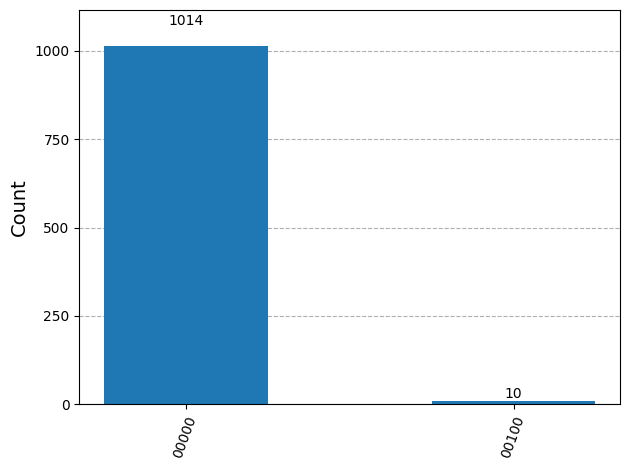

In [29]:
plot_histogram(counts[0])

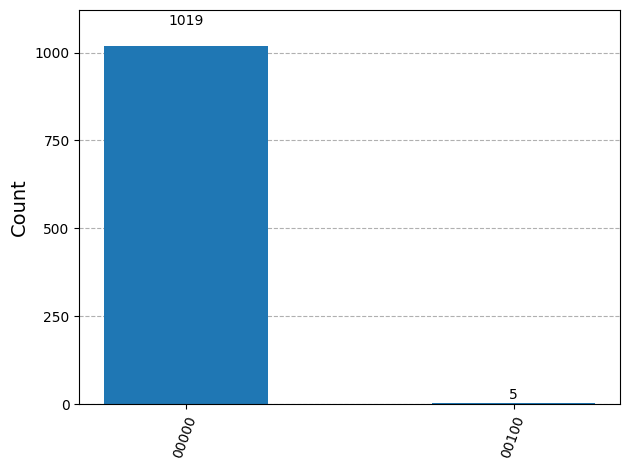

In [30]:
plot_histogram(counts[7])

In [31]:
for i in range(9):
    for j in range(1,10-i):
        # Set the parament theta about different point
        theta_1 = theta_list[i]
        theta_2 = theta_list[i+j]
        #Achieve the quantum circuit via qiskit
        qc.h(qr[2])
        qc.h(qr[1])
        qc.h(qr[4])
        qc.u(float(theta_1), pi, pi, qr[1])
        qc.u(float(theta_2), pi, pi, qr[4])
        qc.cswap(qr[2], qr[1], qr[4])
        qc.h(qr[2])

        qc.measure(qr[2], cr[2])
        qc.draw()

<ipython-input-31-72b2b7022ce1>:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_1), pi, pi, qr[1])
<ipython-input-31-72b2b7022ce1>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_2), pi, pi, qr[4])


In [32]:
theta_1 = theta_list[0]
theta_2 = theta_list[1]
        #Achieve the quantum circuit via qiskit
qc.h(qr[2])
qc.h(qr[1])
qc.h(qr[4])
qc.u(float(theta_1), pi, pi, qr[1])
qc.u(float(theta_2), pi, pi, qr[4])
qc.cswap(qr[2], qr[1], qr[4])
qc.h(qr[2])

qc.measure(qr[2], cr[2])
qc.draw()

<ipython-input-32-98c01c4ee3ae>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_1), pi, pi, qr[1])
<ipython-input-32-98c01c4ee3ae>:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  qc.u(float(theta_2), pi, pi, qr[4])


»
qr_0: ─|0>─────────|0>──────────|0>──|0>──|0>─────────|0>────────»
      ┌───┐┌─────────────────┐           ┌───┐┌─────────────────┐»
qr_1: ┤ H ├┤ U(-0.33821,π,π) ├───X───|0>─┤ H ├┤ U(-0.33821,π,π) ├»
      ├───┤└─────────────────┘   │  ┌───┐└───┘└───────┬─┬───────┘»
qr_2: ┤ H ├──────────────────────■──┤ H ├─────────────┤M├────────»
      └───┘                      │  └───┘             └╥┘        »
qr_3: ─|0>─────────|0>───────────┼───|0>──|0>──────────╫─────────»
      ┌───┐┌──────────────────┐  │       ┌───┐         ║         »
qr_4: ┤ H ├┤ U(0.0098121,π,π) ├──X───|0>─┤ H ├─────────╫─────────»
      └───┘└──────────────────┘          └───┘         ║         »
cr: 5/═════════════════════════════════════════════════╩═════════»
                                                       2         »
«                                                                     »
«qr_0: ────────|0>─────────|0>──|0>──|0>──|0>──|0>─────────|0>────────»
«                                             ┌───┐┌─────────────────┐»
«qr_1: ───────────────────────────────X───|0>─┤ H ├┤ U(-0.33821,π,π) ├»
«                         ┌───┐       │  ┌───┐└───┘└───────┬─┬───────┘»
«qr_2: ────────|0>────────┤ H ├───────■──┤ H ├─────────────┤M├────────»
«                         └───┘       │  └───┘             └╥┘        »
«qr_3: ────────|0>─────────|0>──|0>───┼───|0>──|0>──────────╫─────────»
«      ┌─────────────────┐            │       ┌───┐         ║         »
«qr_4: ┤ U(-0.17682,π,π) ├────────────X───|0>─┤ H ├─────────╫─────────»
«      └─────────────────┘                    └───┘         ║         »
«cr: 5/═════════════════════════════════════════════════════╩═════════»
«                                                           2         »
«                                                                     »
«qr_0: ────────|0>─────────|0>──|0>──|0>──|0>──|0>─────────|0>────────»
«                                             ┌───┐┌─────────────────┐»
«qr_1: ───────────────────────────────X───|0>─┤ H ├┤ U(-0.33821,π,π) ├»
«                         ┌───┐       │  ┌───┐└───┘└───────┬─┬───────┘»
«qr_2: ────────|0>────────┤ H ├───────■──┤ H ├─────────────┤M├────────»
«                         └───┘       │  └───┘             └╥┘        »
«qr_3: ────────|0>─────────|0>──|0>───┼───|0>──|0>──────────╫─────────»
«      ┌─────────────────┐            │       ┌───┐         ║         »
«qr_4: ┤ U(-0.22688,π,π) ├────────────X───|0>─┤ H ├─────────╫─────────»
«      └─────────────────┘                    └───┘         ║         »
«cr: 5/═════════════════════════════════════════════════════╩═════════»
«                                                           2         »
«                                                                     »
«qr_0: ────────|0>─────────|0>──|0>──|0>──|0>──|0>─────────|0>────────»
«                                             ┌───┐┌─────────────────┐»
«qr_1: ───────────────────────────────X───|0>─┤ H ├┤ U(-0.33821,π,π) ├»
«                         ┌───┐       │  ┌───┐└───┘└───────┬─┬───────┘»
«qr_2: ────────|0>────────┤ H ├───────■──┤ H ├─────────────┤M├────────»
«                         └───┘       │  └───┘             └╥┘        »
«qr_3: ────────|0>─────────|0>──|0>───┼───|0>──|0>──────────╫─────────»
«      ┌─────────────────┐            │       ┌───┐         ║         »
«qr_4: ┤ U(-0.21652,π,π) ├────────────X───|0>─┤ H ├─────────╫─────────»
«      └─────────────────┘                    └───┘         ║         »
«cr: 5/═════════════════════════════════════════════════════╩═════════»
«                                                           2         »
«                                                                     »
«qr_0: ────────|0>─────────|0>──|0>──|0>──|0>──|0>─────────|0>────────»
«                                             ┌───┐┌─────────────────┐»
«qr_1: ───────────────────────────────X───|0>─┤ H ├┤ U(-0.33821,π,π) ├»
«                         ┌───┐       │  ┌───┐└───┘└───────┬─┬───────┘»
«qr_2: ────────|0>────────

In [33]:
!pip install pennylane utils

In [34]:
import helper
import pandas as pd
from utils import *

import time
import numpy as np
import math
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch import nn

from IPython.display import Image

In [35]:
df = pd.read_csv('dataset_MRK_prediction.csv')
df = df.drop(['Date' ,'Unnamed: 0'], axis=1)
df

,Close,Volume,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,...,GSK,LLY,NVS,NYSE,NASDAQ,FT3,FT6,FT9,ARIMA,Close_lead1
0,31.011450,14227229,30.050436,29.200291,29.514006,29.867322,0.353316,0.835852,30.871996,27.528586,...,20.441219,22.546120,26.214659,6671.140137,2017.979980,55.454947,50.337802,47.947327,31.011450,31.440840
1,31.440840,20081566,30.318975,29.299346,29.688906,30.115697,0.426791,0.963549,31.226444,27.372247,...,20.290920,22.639698,26.532934,6697.220215,2024.229980,55.359252,50.140845,47.659130,31.440840,31.183207
2,31.183207,10438080,30.564340,29.420211,29.822316,30.283528,0.461212,1.026446,31.473102,27.367319,...,20.280550,22.492653,26.608170,6687.939941,2024.430054,55.263482,49.944470,47.372320,31.183207,31.364504
3,31.364504,10302154,30.858779,29.556525,29.957940,30.452906,0.494965,1.086420,31.729366,27.383684,...,20.513784,22.800129,26.984316,6722.310059,2027.729980,55.167638,49.748691,47.086936,31.364504,30.839695
4,30.839695,12640452,30.973283,29.664667,30.034423,30.513340,0.478916,1.094567,31.853801,27.475534,...,20.285738,22.459227,26.857002,6709.040039,2028.770020,55.071723,49.553518,46.803017,30.839695,30.944656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,78.301529,13675457,75.931026,74.702836,75.305196,75.725497,0.420300,1.705192,78.113220,71.292452,...,38.856968,148.141144,82.393753,12302.190430,9682.910156,57.910147,55.622779,55.790021,76.887436,77.814888
2713,77.814888,9292930,76.515814,74.863687,75.491099,76.046941,0.555842,1.816324,78.496336,71.231038,...,38.423382,146.373550,81.836136,12286.980469,9615.809570,57.817099,55.415062,55.480641,78.191500,78.492363
2714,78.492363,10413347,77.157852,75.097238,75.713415,76.423160,0.709745,1.857931,78.813100,71.381377,...,38.469505,144.916718,82.576424,12641.440430,9814.080078,57.723926,55.207594,55.171523,77.972240,79.103050
2715,79.103050,9956838,77.684024,75.428935,75.964499,76.835451,0.870952,1.960788,79.350511,71.507360,...,39.087601,144.916718,82.364914,12836.599609,9924.750000,57.630627,55.000389,54.862711,78.309688,78.492363


In [36]:
target = "Close_lead1"

In [37]:
features = list(df.columns.difference(["Close", 'Close_lead1']))

In [38]:
features

['12ema',
 '20sd',
 '26ema',
 'AMGN',
 'ARIMA',
 'BMY',
 'FT3',
 'FT6',
 'FT9',
 'GSK',
 'JNJ',
 'LLY',
 'MACD',
 'NASDAQ',
 'NVS',
 'NYSE',
 'PFE',
 'SNP',
 'SNY',
 'VTRS',
 'VZ',
 'Volume',
 'ema',
 'log_momentum',
 'lower_band',
 'ma21',
 'ma7',
 'momentum',
 'neg',
 'neu',
 'pos',
 'upper_band']

In [39]:
size = int(len(df) * 0.67)

df_train = df.loc[:size].copy()
df_test = df.loc[size:].copy()

In [40]:
target_mean = df_train[target].mean()
target_stdev = df_train[target].std()

for c in df_train.columns:
    mean = df_train[c].mean()
    stdev = df_train[c].std()

    df_train[c] = (df_train[c] - mean) / stdev
    df_test[c] = (df_test[c] - mean) / stdev

In [41]:
import sys
import os
module_path = '/content'
if module_path not in sys.path:
    sys.path.append(module_path)

In [42]:
import torch
from torch import nn
from torch.utils.data import Dataset
import pennylane as qml

class SequenceDataset(Dataset):
    def __init__(self, dataframe, target, features, sequence_length=5):
        self.features = features
        self.target = target
        self.sequence_length = sequence_length
        self.y = torch.tensor(dataframe[self.target].values).float()
        self.X = torch.tensor(dataframe[self.features].values).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        if i >= self.sequence_length - 1:
            i_start = i - self.sequence_length + 1
            x = self.X[i_start:(i + 1), :]
        else:
            padding = self.X[0].repeat(self.sequence_length - i - 1, 1)
            x = self.X[0:(i + 1), :]
            x = torch.cat((padding, x), 0)

        return x, self.y[i]

class ShallowRegressionLSTM(nn.Module):
    def __init__(self, num_sensors, hidden_units):
        super().__init__()
        self.num_sensors = num_sensors  # this is the number of features
        self.hidden_units = hidden_units
        self.num_layers = 1

        self.lstm = nn.LSTM(
            input_size=num_sensors,
            hidden_size=hidden_units,
            batch_first=True,
            num_layers=self.num_layers
        )

        self.linear = nn.Linear(in_features=self.hidden_units, out_features=1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_units).requires_grad_()
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_units).requires_grad_()

        _, (hn, _) = self.lstm(x, (h0, c0))
        out = self.linear(hn[0]).flatten()  # First dim of Hn is num_layers, which is set to 1 above.

        return out

class QLSTM(nn.Module):
    def __init__(self,
                input_size,
                hidden_size,
                n_qubits=4,
                n_qlayers=1,
                n_vrotations=3,
                batch_first=True,
                return_sequences=False,
                return_state=False,
                backend="default.qubit"):
        super(QLSTM, self).__init__()
        self.n_inputs = input_size
        self.hidden_size = hidden_size
        self.concat_size = self.n_inputs + self.hidden_size
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers
        self.n_vrotations = n_vrotations
        self.backend = backend  # "default.qubit", "qiskit.basicaer", "qiskit.ibm"

        self.batch_first = batch_first
        self.return_sequences = return_sequences
        self.return_state = return_state

        self.wires_forget = [f"wire_forget_{i}" for i in range(self.n_qubits)]
        self.wires_input = [f"wire_input_{i}" for i in range(self.n_qubits)]
        self.wires_update = [f"wire_update_{i}" for i in range(self.n_qubits)]
        self.wires_output = [f"wire_output_{i}" for i in range(self.n_qubits)]

        self.dev_forget = qml.device(self.backend, wires=self.wires_forget)
        self.dev_input = qml.device(self.backend, wires=self.wires_input)
        self.dev_update = qml.device(self.backend, wires=self.wires_update)
        self.dev_output = qml.device(self.backend, wires=self.wires_output)

        #self.dev_forget = qml.device(self.backend, wires=self.n_qubits)
        #self.dev_input = qml.device(self.backend, wires=self.n_qubits)
        #self.dev_update = qml.device(self.backend, wires=self.n_qubits)
        #self.dev_output = qml.device(self.backend, wires=self.n_qubits)

        def ansatz(params, wires_type):
            # Entangling layer.
            for i in range(1,3):
                for j in range(self.n_qubits):
                    if j + i < self.n_qubits:
                        qml.CNOT(wires=[wires_type[j], wires_type[j + i]])
                    else:
                        qml.CNOT(wires=[wires_type[j], wires_type[j + i - self.n_qubits]])

            # Variational layer.
            for i in range(self.n_qubits):
                qml.RX(params[0][i], wires=wires_type[i])
                qml.RY(params[1][i], wires=wires_type[i])
                qml.RZ(params[2][i], wires=wires_type[i])

        def VQC(features, weights, wires_type):
            # Preproccess input data to encode the initial state.
            #qml.templates.AngleEmbedding(features, wires=wires_type)
            ry_params = [torch.arctan(feature) for feature in features]
            rz_params = [torch.arctan(feature**2) for feature in features]
            for i in range(self.n_qubits):
                qml.Hadamard(wires=wires_type[i])
                qml.RY(ry_params[i], wires=wires_type[i])
                qml.RZ(ry_params[i], wires=wires_type[i])

            #Variational block.
            qml.layer(ansatz, self.n_qlayers, weights, wires_type = wires_type)

        def _circuit_forget(inputs, weights):
            VQC(inputs, weights, self.wires_forget)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_forget]
        self.qlayer_forget = qml.QNode(_circuit_forget, self.dev_forget, interface="torch")

        def _circuit_input(inputs, weights):
            VQC(inputs, weights, self.wires_input)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_input]
        self.qlayer_input = qml.QNode(_circuit_input, self.dev_input, interface="torch")

        def _circuit_update(inputs, weights):
            VQC(inputs, weights, self.wires_update)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_update]
        self.qlayer_update = qml.QNode(_circuit_update, self.dev_update, interface="torch")

        def _circuit_output(inputs, weights):
            VQC(inputs, weights, self.wires_output)
            return [qml.expval(qml.PauliZ(wires=i)) for i in self.wires_output]
        self.qlayer_output = qml.QNode(_circuit_output, self.dev_output, interface="torch")

        weight_shapes = {"weights": (self.n_qlayers, self.n_vrotations, self.n_qubits)}
        print(f"weight_shapes = (n_qlayers, n_vrotations, n_qubits) = ({self.n_qlayers}, {self.n_vrotations}, {self.n_qubits})")

        self.clayer_in = torch.nn.Linear(self.concat_size, self.n_qubits)
        self.VQC = {
            'forget': qml.qnn.TorchLayer(self.qlayer_forget, weight_shapes),
            'input': qml.qnn.TorchLayer(self.qlayer_input, weight_shapes),
            'update': qml.qnn.TorchLayer(self.qlayer_update, weight_shapes),
            'output': qml.qnn.TorchLayer(self.qlayer_output, weight_shapes)
        }
        self.clayer_out = torch.nn.Linear(self.n_qubits, self.hidden_size)
        #self.clayer_out = [torch.nn.Linear(n_qubits, self.hidden_size) for _ in range(4)]

    def forward(self, x, init_states=None):
        '''
        x.shape is (batch_size, seq_length, feature_size)
        recurrent_activation -> sigmoid
        activation -> tanh
        '''
        if self.batch_first is True:
            batch_size, seq_length, features_size = x.size()
        else:
            seq_length, batch_size, features_size = x.size()

        hidden_seq = []
        if init_states is None:
            h_t = torch.zeros(batch_size, self.hidden_size)  # hidden state (output)
            c_t = torch.zeros(batch_size, self.hidden_size)  # cell state
        else:
            # for now we ignore the fact that in PyTorch you can stack multiple RNNs
            # so we take only the first elements of the init_states tuple init_states[0][0], init_states[1][0]
            h_t, c_t = init_states
            h_t = h_t[0]
            c_t = c_t[0]

        for t in range(seq_length):
            # get features from the t-th element in seq, for all entries in the batch
            x_t = x[:, t, :]

            # Concatenate input and hidden state
            v_t = torch.cat((h_t, x_t), dim=1)

            # match qubit dimension
            y_t = self.clayer_in(v_t)

            f_t = torch.sigmoid(self.clayer_out(self.VQC['forget'](y_t)))  # forget block
            i_t = torch.sigmoid(self.clayer_out(self.VQC['input'](y_t)))  # input block
            g_t = torch.tanh(self.clayer_out(self.VQC['update'](y_t)))  # update block
            o_t = torch.sigmoid(self.clayer_out(self.VQC['output'](y_t))) # output block

            c_t = (f_t * c_t) + (i_t * g_t)
            h_t = o_t * torch.tanh(c_t)

            hidden_seq.append(h_t.unsqueeze(0))
        hidden_seq = torch.cat(hidden_seq, dim=0)
        hidden_seq = hidden_seq.transpose(0, 1).contiguous()
        return hidden_seq, (h_t, c_t)

class QShallowRegressionLSTM(nn.Module):
    def __init__(self, num_sensors, hidden_units, n_qubits=0, n_qlayers=1):
        super().__init__()
        self.num_sensors = num_sensors  # this is the number of features
        self.hidden_units = hidden_units
        self.num_layers = 1

        #self.lstm = nn.LSTM(
        #    input_size=num_sensors,
        #    hidden_size=hidden_units,
        #    batch_first=True,
        #    num_layers=self.num_layers
        #)

        self.lstm = QLSTM(
            input_size=num_sensors,
            hidden_size=hidden_units,
            batch_first=True,
            n_qubits = n_qubits,
            n_qlayers= n_qlayers
        )

        self.linear = nn.Linear(in_features=self.hidden_units, out_features=1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_units).requires_grad_()
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_units).requires_grad_()

        _, (hn, _) = self.lstm(x, (h0, c0))
        out = self.linear(hn).flatten()  # First dim of Hn is num_layers, which is set to 1 above.

        return out

In [43]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
import math

def date_parser(x):
    return datetime.datetime.strptime(x,'%Y-%m-%d')

def get_technical_indicators(dataset, target_col):
    # create 7 and 21 daya moving average
    dataset['ma7'] = dataset[target_col].rolling(window=7).mean()
    dataset['ma21'] = dataset[target_col].rolling(window=21).mean()

    # create MACD: Provides exponential weighted functions.
    dataset['26ema'] = dataset[target_col].ewm(span=26).mean()
    dataset['12ema'] = dataset[target_col].ewm(span=12).mean()
    dataset['MACD'] = (dataset['12ema'] - dataset['26ema'])

    # create Bollinger Bands
    dataset['20sd'] = dataset[target_col].rolling(20).std()
    dataset['upper_band'] = dataset['ma21'] + dataset['20sd'] * 2
    dataset['lower_band'] = dataset['ma21'] - dataset['20sd'] * 2

    # create expoential moving average
    dataset['ema'] = dataset[target_col].ewm(com=0.5).mean()

    # create momentum
    dataset['momentum'] = dataset[target_col] - 1
    dataset['log_momentum'] = np.log(dataset[target_col] - 1)
    return dataset

def plot_technical_indicators(dataset, last_days):
    plt.figure(figsize=(16, 10), dpi=100)
    shape_0 = dataset.shape[0]
    xmacd_ = shape_0-last_days

    dataset = dataset.iloc[-last_days:, :]
    x_ = range(3, dataset.shape[0])
    x_ =list(dataset.index)

    # Plot first subplot
    plt.subplot(2, 1, 1)
    plt.plot(dataset['ma7'],label='MA 7', color='g',linestyle='--')
    plt.plot(dataset['Close'],label='Closing Price', color='b')
    plt.plot(dataset['ma21'],label='MA 21', color='r',linestyle='--')
    plt.plot(dataset['upper_band'],label='Upper Band', color='c')
    plt.plot(dataset['lower_band'],label='Lower Band', color='c')
    plt.fill_between(x_, dataset['lower_band'], dataset['upper_band'], alpha=0.35)
    plt.title('Technical indicators - last {} days.'.format(last_days))
    plt.ylabel('USD')
    plt.legend()

    # Plot second subplot
    plt.subplot(2, 1, 2)
    plt.title('MACD')
    plt.plot(dataset['MACD'],label='MACD', linestyle='-.')
    plt.hlines(15, xmacd_, shape_0, colors='g', linestyles='--')
    plt.hlines(-15, xmacd_, shape_0, colors='g', linestyles='--')
    plt.plot(dataset['log_momentum'],label='Momentum', color='b',linestyle='-')

    plt.legend()
    plt.show()

def get_feature_importance_data(data_income):
    data = data_income.copy()
    y = data['Close']
    X = data.iloc[:, 1:]

    train_samples = int(X.shape[0] * 0.65)

    X_train = X.iloc[:train_samples]
    X_test = X.iloc[train_samples:]

    y_train = y.iloc[:train_samples]
    y_test = y.iloc[train_samples:]

    return (X_train, y_train), (X_test, y_test)

def gelu(x):
    return 0.5 * x * (1 + math.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * math.pow(x, 3))))

def relu(x):
    return max(x, 0)

def lrelu(x):
    return max(0.01*x, x)


In [44]:
from Factory import SequenceDataset

In [45]:
torch.manual_seed(101)

batch_size = 1
sequence_length = 3

train_dataset = SequenceDataset(
    df_train,
    target=target,
    features=features,
    sequence_length=sequence_length
)
test_dataset = SequenceDataset(
    df_test,
    target=target,
    features=features,
    sequence_length=sequence_length
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X, y = next(iter(train_loader))

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: torch.Size([1, 3, 32])
Target shape: torch.Size([1])


In [46]:
def train_model(data_loader, model, loss_function, optimizer):
    num_batches = len(data_loader)
    total_loss = 0
    model.train()

    for X, y in data_loader:
        output = model(X)
        loss = loss_function(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    print(f"Train loss: {avg_loss}")
    return avg_loss

def test_model(data_loader, model, loss_function):

    num_batches = len(data_loader)
    total_loss = 0

    model.eval()
    with torch.no_grad():
        for X, y in data_loader:
            output = model(X)
            total_loss += loss_function(output, y).item()

    avg_loss = total_loss / num_batches
    print(f"Test loss: {avg_loss}")
    return avg_loss

In [47]:
from Factory import ShallowRegressionLSTM

In [48]:
learning_rate = 0.0001
num_hidden_units = 16

model = ShallowRegressionLSTM(num_sensors=len(features), hidden_units=num_hidden_units)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [54]:
classical_loss_train = []
classical_loss_test = []
print("Untrained test\n--------")
start = time.time()
test_loss = test_model(test_loader, model, loss_function)
end = time.time()
print("Execution time", end - start)
classical_loss_test.append(test_loss)

for ix_epoch in range(10):
    print(f"Epoch {ix_epoch}\n---------")
    start = time.time()
    train_loss = train_model(train_loader, model, loss_function, optimizer=optimizer)
    test_loss = test_model(test_loader, model, loss_function)
    end = time.time()
    print("Execution time", end - start)
    classical_loss_train.append(train_loss)
    classical_loss_test.append(test_loss)

Untrained test
--------
Test loss: 8.610089965289253
Execution time 0.8385119438171387
Epoch 0
---------
Train loss: 0.2649586353991367
Test loss: 2.6581177934140356
Execution time 11.075488328933716
Epoch 1
---------
Train loss: 0.035385134256151564
Test loss: 2.1039027116593507
Execution time 6.446008205413818
Epoch 2
---------
Train loss: 0.01829503129585663
Test loss: 1.8549891795527809
Execution time 4.544495105743408
Epoch 3
---------
Train loss: 0.012233800319593938
Test loss: 1.7207610133735345
Execution time 3.8752331733703613
Epoch 4
---------
Train loss: 0.009624062076872861
Test loss: 1.5825360836405633
Execution time 4.57304835319519
Epoch 5
---------
Train loss: 0.008308257886837046
Test loss: 1.5375715868465345
Execution time 5.245168685913086
Epoch 6
---------
Train loss: 0.007497009799235905
Test loss: 1.548389746114092
Execution time 4.767322063446045
Epoch 7
---------
Train loss: 0.0070167517462106374
Test loss: 1.4347328046140695
Execution time 5.883418798446655
Epo

In [55]:
def predict(data_loader, model):
    """Just like `test_loop` function but keep track of the outputs instead of the loss
    function.
    """
    output = torch.tensor([])
    model.eval()
    with torch.no_grad():
        for X, _ in data_loader:
            y_star = model(X)
            output = torch.cat((output, y_star), 0)

    return output

In [56]:
train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

ystar_col = "Model forecast"
df_train[ystar_col] = predict(train_eval_loader, model).numpy()
df_test[ystar_col] = predict(test_loader, model).numpy()

df_out = pd.concat((df_train, df_test))[[target, ystar_col]]

for c in df_out.columns:
    df_out[c] = df_out[c] * target_stdev + target_mean

print(df_out)

      Close_lead1  Model forecast
0       31.440840       30.337940
1       31.183207       30.341499
2       31.364504       30.511726
3       30.839695       30.700321
4       30.944656       30.691414
...           ...             ...
2712    77.814888       61.214890
2713    78.492363       61.303726
2714    79.103050       61.341888
2715    78.492363       61.483589
2716    78.024811       61.434769

[2718 rows x 2 columns]


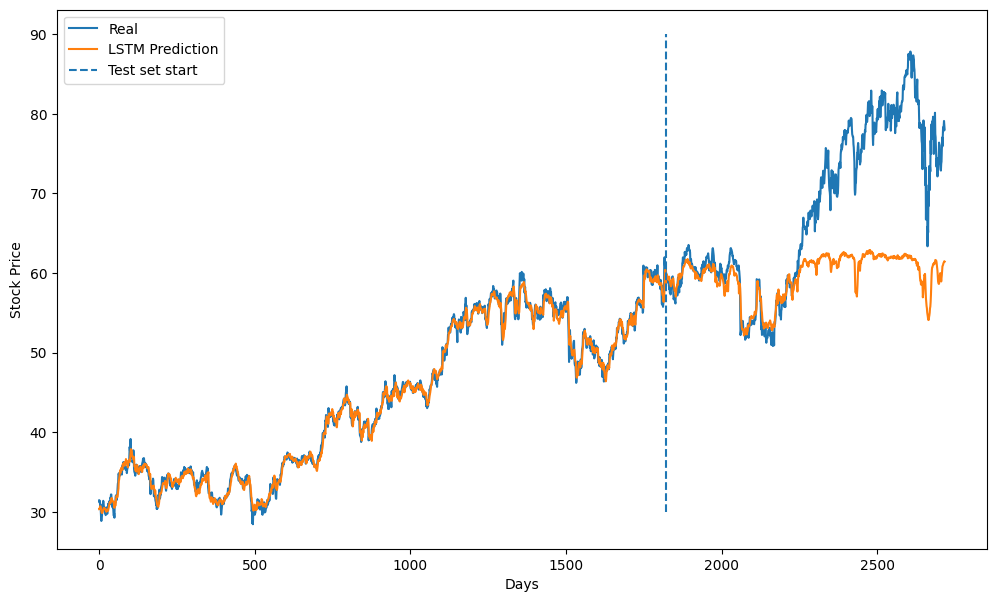

In [57]:
plt.figure(figsize=(12, 7))
plt.plot(range(2718), df_out["Close_lead1"], label = "Real")
plt.plot(range(2718), df_out["Model forecast"], label = "LSTM Prediction")
plt.ylabel('Stock Price')
plt.xlabel('Days')
plt.vlines(size, ymin = 30, ymax = 90, label = "Test set start", linestyles = "dashed")
plt.legend()
plt.show()

Q-Transformer: Untrained test
--------


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Test loss: 7.037205768202991
Execution time 84.73181557655334
Q-Transformer: Epoch 0
---------
Train loss: 0.028007608005934312
Test loss: 0.05256022725430051
Execution time 314.48968029022217
      Close_lead1  QTransformer forecast
0       31.440840              30.034779
1       31.183207              30.104912
2       31.364504              30.271887
3       30.839695              30.513103
4       30.944656              30.559280
...           ...                    ...
2712    77.814888              74.154030
2713    78.492363              74.601501
2714    79.103050              75.188828
2715    78.492363              75.551277
2716    78.024811              75.980080

[2718 rows x 2 columns]


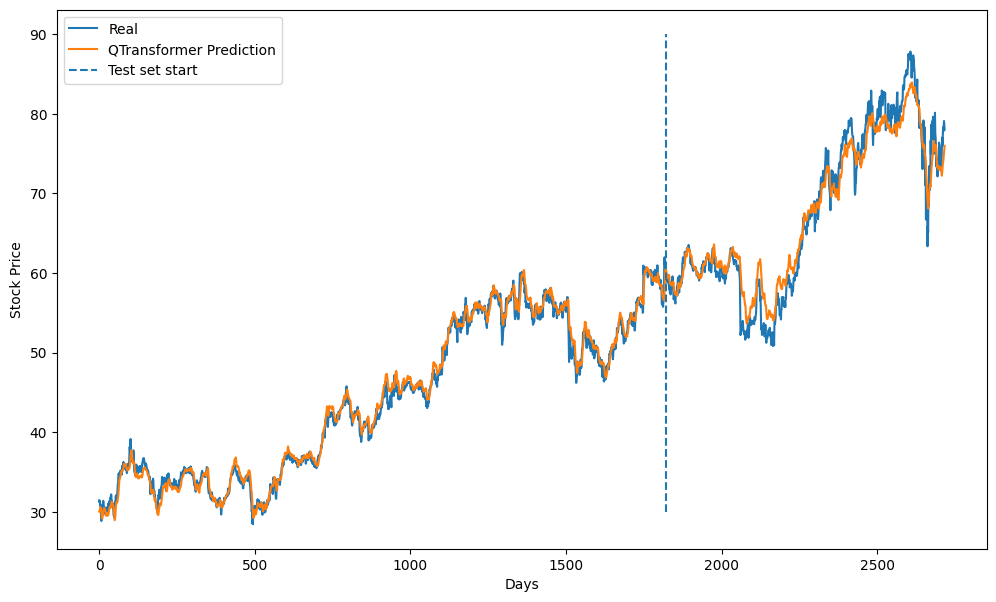

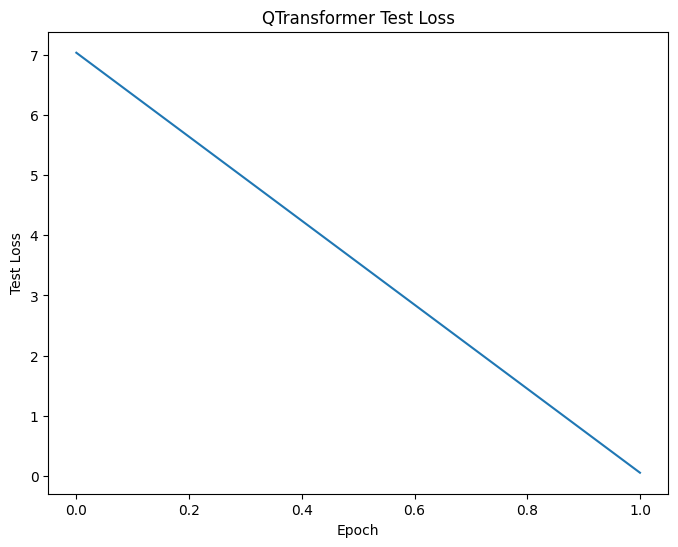

In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
import math

class QAttention(nn.Module):
    """Quantum-enhanced attention mechanism"""
    def __init__(self, embed_dim, n_qubits=4, n_qlayers=2):
        super(QAttention, self).__init__()
        self.embed_dim = embed_dim
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers

        # Define quantum device
        self.dev = qml.device("default.qubit", wires=n_qubits)

        # Linear projections for query, key, value
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        # Output projection
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        # Parameterized quantum circuit parameters
        self.q_params = nn.Parameter(torch.randn(n_qlayers, n_qubits, 3))

        # Define quantum circuit
        @qml.qnode(self.dev, interface="torch")
        def q_circuit(inputs, params):
            # Encode inputs
            for i in range(self.n_qubits):
                qml.RY(inputs[i], wires=i)

            # Apply variational quantum layers
            for l in range(self.n_qlayers):
                for i in range(self.n_qubits):
                    qml.RX(params[l, i, 0], wires=i)
                    qml.RY(params[l, i, 1], wires=i)
                    qml.RZ(params[l, i, 2], wires=i)

                # Entangling layers
                for i in range(self.n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[self.n_qubits - 1, 0])  # Close the loop

            # Return expectation values
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.q_circuit = q_circuit

    def forward(self, query, key, value):
        batch_size = query.size(0)
        seq_len = query.size(1)

        # Linear projections
        q = self.query(query)
        k = self.key(key)
        v = self.value(value)

        # Calculate attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.embed_dim)

        # Apply quantum enhancement to attention weights
        quantum_enhanced = torch.zeros_like(scores)

        # Process each element through quantum circuit
        # For efficiency, we'll process a subset of the attention matrix
        for i in range(min(seq_len, 4)):  # Process max 4 elements per sequence for efficiency
            for j in range(min(seq_len, 4)):
                # Extract attention weights for quantum processing
                flattened = scores[:, i, j].reshape(-1)

                # Process in batches to avoid too many circuit evaluations
                for b in range(0, batch_size, self.n_qubits):
                    # Prepare inputs for quantum circuit (clamp to [-π, π])
                    q_inputs = torch.tanh(flattened[b:b+self.n_qubits]) * math.pi
                    if len(q_inputs) < self.n_qubits:
                        q_inputs = F.pad(q_inputs, (0, self.n_qubits - len(q_inputs)))

                    # Get quantum circuit outputs
                    q_out = torch.tensor(self.q_circuit(q_inputs, self.q_params))

                    # Update the corresponding attention weights
                    end_idx = min(b + self.n_qubits, batch_size)
                    quantum_enhanced[b:end_idx, i, j] = q_out[:end_idx-b]

        # Blend classical and quantum attention (weighted sum)
        alpha = 0.3  # Blending factor
        enhanced_scores = (1 - alpha) * scores + alpha * quantum_enhanced

        # Apply softmax
        attention = F.softmax(enhanced_scores, dim=-1)

        # Apply attention weights to values
        output = torch.matmul(attention, v)

        # Final projection
        output = self.out_proj(output)

        return output


class QTransformerEncoderLayer(nn.Module):
    """Quantum-enhanced Transformer encoder layer"""
    def __init__(self, embed_dim, n_heads=4, ff_dim=128, dropout=0.1, n_qubits=4, n_qlayers=2):
        super(QTransformerEncoderLayer, self).__init__()

        # Multi-head quantum attention
        self.self_attn = nn.MultiheadAttention(embed_dim, n_heads)
        self.q_attention = QAttention(embed_dim, n_qubits, n_qlayers)

        # Feed-forward network
        self.linear1 = nn.Linear(embed_dim, ff_dim)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(ff_dim, embed_dim)

        # Layer normalization
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        # Dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        # Use standard multi-head attention and blend with quantum attention
        src2 = self.norm1(src)

        # Classical multi-head attention
        classical_out, _ = self.self_attn(src2, src2, src2, attn_mask=src_mask)

        # Quantum attention (reshaped for compatibility)
        q_input = src2.transpose(0, 1)  # Convert to [batch, seq, features]
        quantum_out = self.q_attention(q_input, q_input, q_input).transpose(0, 1)  # Back to [seq, batch, features]

        # Blend approaches (weighted sum)
        blend_factor = 0.3
        attn_output = (1 - blend_factor) * classical_out + blend_factor * quantum_out

        # First residual connection
        src = src + self.dropout1(attn_output)

        # Feed-forward network
        src2 = self.norm2(src)
        src2 = self.linear2(self.dropout(F.relu(self.linear1(src2))))

        # Second residual connection
        src = src + self.dropout2(src2)

        return src


class QTransformer(nn.Module):
    """Quantum Transformer for time series forecasting"""
    def __init__(self, input_dim, hidden_dim=64, n_heads=4, n_layers=2, n_qubits=4, n_qlayers=2, dropout=0.1):
        super(QTransformer, self).__init__()

        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim, dropout)

        # Encoder layers
        self.encoder_layers = nn.ModuleList([
            QTransformerEncoderLayer(
                hidden_dim, n_heads=n_heads, dropout=dropout,
                n_qubits=n_qubits, n_qlayers=n_qlayers
            ) for _ in range(n_layers)
        ])

        # Final prediction layer
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [batch, seq_len, features]

        # Apply embedding and positional encoding
        x = self.embedding(x)  # [batch, seq_len, hidden_dim]
        x = x.transpose(0, 1)  # [seq_len, batch, hidden_dim]
        x = self.pos_encoder(x)

        # Apply encoder layers
        for layer in self.encoder_layers:
            x = layer(x)

        # Global average pooling across sequence length
        x = x.transpose(0, 1)  # [batch, seq_len, hidden_dim]
        x = torch.mean(x, dim=1)  # [batch, hidden_dim]

        # Final prediction
        output = self.fc_out(x)  # [batch, 1]

        return output


class PositionalEncoding(nn.Module):
    """Positional encoding for sequences"""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)


# Code to add Q-Transformer to the existing training pipeline
def train_qtransformer():
    learning_rate = 0.001
    hidden_dim = 32
    n_heads = 2
    n_layers = 1
    n_qubits = 4
    n_qlayers = 1

    # Initialize the model
    qtransformer_model = QTransformer(
        input_dim=len(features),
        hidden_dim=hidden_dim,
        n_heads=n_heads,
        n_layers=n_layers,
        n_qubits=n_qubits,
        n_qlayers=n_qlayers
    )

    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(qtransformer_model.parameters(), lr=learning_rate)

    qtransformer_loss_train = []
    qtransformer_loss_test = []

    print("Q-Transformer: Untrained test\n--------")
    start = time.time()
    test_loss = test_model(test_loader, qtransformer_model, loss_function)
    end = time.time()
    print("Execution time", end - start)
    qtransformer_loss_test.append(test_loss)

    for ix_epoch in range(1):
        print(f"Q-Transformer: Epoch {ix_epoch}\n---------")
        start = time.time()
        train_loss = train_model(train_loader, qtransformer_model, loss_function, optimizer=optimizer)
        test_loss = test_model(test_loader, qtransformer_model, loss_function)
        end = time.time()
        print("Execution time", end - start)
        qtransformer_loss_train.append(train_loss)
        qtransformer_loss_test.append(test_loss)

    # Generate predictions
    train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    ystar_col_QT = "QTransformer forecast"

    df_train[ystar_col_QT] = predict(train_eval_loader, qtransformer_model).numpy()
    df_test[ystar_col_QT] = predict(test_loader, qtransformer_model).numpy()

    df_out_QT = pd.concat((df_train, df_test))[[target, ystar_col_QT]]

    for c in df_out_QT.columns:
        df_out_QT[c] = df_out_QT[c] * target_stdev + target_mean

    print(df_out_QT)

    # Plot results
    plt.figure(figsize=(12, 7))
    plt.plot(range(2718), df_out_QT["Close_lead1"], label="Real")
    plt.plot(range(2718), df_out_QT["QTransformer forecast"], label="QTransformer Prediction")
    plt.ylabel('Stock Price')
    plt.xlabel('Days')
    plt.vlines(size, ymin=30, ymax=90, label="Test set start", linestyles="dashed")
    plt.legend()
    plt.show()

    # Plot loss
    plt.figure(figsize=(8, 6))
    plt.plot(range(2), qtransformer_loss_test)
    plt.ylabel('Test Loss')
    plt.xlabel('Epoch')
    plt.title('QTransformer Test Loss')
    plt.show()

    # Compare all models
    plt.figure(figsize=(14, 8))
    plt.plot(range(len(df_out["Close_lead1"])), df_out["Close_lead1"], label="Real")
    plt.plot(range(len(df_out["Model forecast"])), df_out["Model forecast"], label="LSTM Prediction")
    #plt.plot(range(len(df_out_Q["Model forecast"])), df_out_Q["Model forecast"], label="QLSTM Prediction")
    plt.plot(range(len(df_out_QT["QTransformer forecast"])), df_out_QT["QTransformer forecast"], label="QTransformer Prediction")
    plt.ylabel('Stock Price')
    plt.xlabel('Days')
    plt.vlines(size, ymin=30, ymax=90, label="Test set start", linestyles="dashed")
    plt.legend()
    plt.title('Comparison of All Models')
    plt.show()

    return qtransformer_model, qtransformer_loss_train, qtransformer_loss_test, df_out_QT

# Call this function after training the LSTM and QLSTM models
qtransformer_model, qtransformer_loss_train, qtransformer_loss_test, df_out_QT = train_qtransformer()

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
import numpy as np
import math
import time
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader

class QLSTMCell(nn.Module):
    """
    Quantum-enhanced LSTM cell implementation with consistent dtypes
    """
    def __init__(self, input_size, hidden_size, n_qubits=4, n_qlayers=1):
        super(QLSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers

        # Define quantum device
        self.dev = qml.device("default.qubit", wires=n_qubits)

        # Trainable parameters for quantum circuit - use float32 consistently
        self.q_params = nn.Parameter(torch.randn(n_qlayers, n_qubits, 3, dtype=torch.float32))

        # Classical parts of the LSTM cell
        self.wih = nn.Linear(input_size, hidden_size * 4, dtype=torch.float32)  # Input to hidden weights
        self.whh = nn.Linear(hidden_size, hidden_size * 4, dtype=torch.float32)  # Hidden to hidden weights

        # Output projection after quantum processing
        self.q_out = nn.Linear(n_qubits, hidden_size, dtype=torch.float32)

        # Define quantum circuit
        @qml.qnode(self.dev, interface="torch")
        def q_circuit(inputs, params):
            # Encode classical input data into quantum state
            # Normalize inputs to range [-π, π]
            inputs_normalized = torch.tanh(inputs) * math.pi

            # Apply RY gates to encode the input
            for i in range(self.n_qubits):
                qml.RY(inputs_normalized[i].item(), wires=i)

            # Apply variational quantum circuit
            for l in range(self.n_qlayers):
                # Rotation gates
                for i in range(self.n_qubits):
                    qml.RX(params[l, i, 0].item(), wires=i)
                    qml.RY(params[l, i, 1].item(), wires=i)
                    qml.RZ(params[l, i, 2].item(), wires=i)

                # Entangling gates
                for i in range(self.n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[self.n_qubits - 1, 0])  # Close the loop

            # Return expectation values
            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.q_circuit = q_circuit

    def forward(self, x, hidden):
        # Ensure consistent dtype
        x = x.to(torch.float32)
        h_prev, c_prev = hidden[0].to(torch.float32), hidden[1].to(torch.float32)

        # Compute gates using standard LSTM operations
        gates = self.wih(x) + self.whh(h_prev)

        # Split gates into components
        input_gate, forget_gate, cell_gate, output_gate = gates.chunk(4, dim=1)

        # Apply sigmoid and tanh activations
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        cell_gate = torch.tanh(cell_gate)
        output_gate = torch.sigmoid(output_gate)

        # Update cell state
        c_next = forget_gate * c_prev + input_gate * cell_gate

        # Compute hidden state through quantum circuit
        # Process cell state through quantum circuit in batches
        h_next = torch.zeros_like(h_prev)
        batch_size = c_next.size(0)

        for b in range(batch_size):
            # Take a portion of the cell state for quantum processing
            c_sample = c_next[b, :self.n_qubits]
            if len(c_sample) < self.n_qubits:
                c_sample = F.pad(c_sample, (0, self.n_qubits - len(c_sample)), "constant", 0)

            # Process through quantum circuit
            q_out = torch.tensor(self.q_circuit(c_sample, self.q_params), dtype=torch.float32)

            # Map quantum output to hidden state dimension
            q_hidden = self.q_out(q_out)

            # Apply output gate and update hidden state
            h_next[b] = output_gate[b] * torch.tanh(q_hidden)

        return h_next, c_next


class QLSTM(nn.Module):
    """
    Quantum LSTM layer
    """
    def __init__(self, input_size, hidden_size, n_qubits=4, n_qlayers=1, batch_first=True):
        super(QLSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_first = batch_first
        self.n_qubits = min(n_qubits, hidden_size)  # Cannot use more qubits than hidden size

        # Create QLSTM cell
        self.cell = QLSTMCell(input_size, hidden_size, n_qubits, n_qlayers)

    def forward(self, x, hidden=None):
        # Ensure x is float32
        x = x.to(torch.float32)

        if self.batch_first:
            batch_size, seq_len, _ = x.size()
        else:
            seq_len, batch_size, _ = x.size()

        # Initialize hidden state if not provided
        if hidden is None:
            h0 = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=torch.float32)
            c0 = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=torch.float32)
            hidden = (h0, c0)
        else:
            # Ensure hidden state has consistent dtype
            hidden = (hidden[0].to(torch.float32), hidden[1].to(torch.float32))

        # Containers for output sequence and final states
        outputs = []
        h_n = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=x.device)
        c_n = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=x.device)

        # Iterate through sequence
        for t in range(seq_len):
            if self.batch_first:
                xt = x[:, t, :]
            else:
                xt = x[t]

            # Process through QLSTM cell
            h, c = self.cell(xt, hidden)
            hidden = (h, c)
            outputs.append(h)

            # Store final state
            if t == seq_len - 1:
                h_n = h
                c_n = c

        # Stack outputs
        if self.batch_first:
            outputs = torch.stack(outputs, dim=1)
        else:
            outputs = torch.stack(outputs, dim=0)

        return outputs, (h_n, c_n)


class QShallowRegressionLSTM(nn.Module):
    """
    Complete Quantum LSTM model for regression
    """
    def __init__(self, num_sensors, hidden_units, n_qubits=4, n_qlayers=1):
        super(QShallowRegressionLSTM, self).__init__()

        # Quantum LSTM layer
        self.lstm = QLSTM(
            input_size=num_sensors,
            hidden_size=hidden_units,
            n_qubits=min(n_qubits, hidden_units),
            n_qlayers=n_qlayers,
            batch_first=True
        )

        # Regression head
        self.linear = nn.Linear(hidden_units, 1, dtype=torch.float32)

    def forward(self, x):
        # Ensure input is float32
        x = x.to(torch.float32)

        # Forward pass through QLSTM layer
        _, (hidden, _) = self.lstm(x)

        # Pass through regressor head
        return self.linear(hidden)


def train_model(data_loader, model, loss_function, optimizer):
    """Training function with dtype handling"""
    num_batches = len(data_loader)
    total_loss = 0
    model.train()

    for X, y in data_loader:
        # Ensure consistent dtypes
        X = X.to(torch.float32)
        y = y.to(torch.float32)

        output = model(X)
        loss = loss_function(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    print(f"Train loss: {avg_loss}")
    return avg_loss


def test_model(data_loader, model, loss_function):
    """Testing function with dtype handling"""
    num_batches = len(data_loader)
    total_loss = 0

    model.eval()
    with torch.no_grad():
        for X, y in data_loader:
            # Ensure consistent dtypes
            X = X.to(torch.float32)
            y = y.to(torch.float32)

            output = model(X)
            total_loss += loss_function(output, y).item()

    avg_loss = total_loss / num_batches
    print(f"Test loss: {avg_loss}")
    return avg_loss


def predict(data_loader, model):
    """Prediction function with dtype handling"""
    output = torch.tensor([], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        for X, _ in data_loader:
            # Ensure consistent dtype
            X = X.to(torch.float32)

            y_star = model(X)
            output = torch.cat((output, y_star), 0)

    return output


# Main training function
def train_qlstm_model(train_dataset, test_dataset, train_loader, test_loader,
                      features, target, target_stdev, target_mean, size,
                      df_train, df_test, batch_size=1):
    print("\n" + "="*50)
    print("QUANTUM LSTM (QLSTM) TRAINING")
    print("="*50 + "\n")

    # Set parameters
    learning_rate = 0.01  # Reduced learning rate for stability
    num_hidden_units = 16
    n_qubits = 4
    n_qlayers = 1

    # Initialize model, loss function, optimizer
    qlstm_model = QShallowRegressionLSTM(
        num_sensors=len(features),
        hidden_units=num_hidden_units,
        n_qubits=n_qubits,
        n_qlayers=n_qlayers
    )

    # Ensure all model parameters are float32
    for param in qlstm_model.parameters():
        param.data = param.data.to(torch.float32)

    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(qlstm_model.parameters(), lr=learning_rate)

    # Track loss
    qlstm_loss_train = []
    qlstm_loss_test = []

    # Initial test
    print("Untrained test\n--------")
    start = time.time()
    test_loss = test_model(test_loader, qlstm_model, loss_function)
    end = time.time()
    print(f"Execution time: {end - start:.2f} seconds")
    qlstm_loss_test.append(test_loss)

    # Training loop
    num_epochs = 1  # Reduced for faster execution
    for ix_epoch in range(num_epochs):
        print(f"Epoch {ix_epoch+1}/{num_epochs}\n---------")
        start = time.time()
        train_loss = train_model(train_loader, qlstm_model, loss_function, optimizer=optimizer)
        test_loss = test_model(test_loader, qlstm_model, loss_function)
        end = time.time()
        print(f"Execution time: {end - start:.2f} seconds")
        qlstm_loss_train.append(train_loss)
        qlstm_loss_test.append(test_loss)

    # Generate predictions
    train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    ystar_col_Q = "QLSTM forecast"

    # Get predictions and ensure they're numpy arrays of the right dtype
    train_preds = predict(train_eval_loader, qlstm_model).detach().numpy().astype(np.float64)
    test_preds = predict(test_loader, qlstm_model).detach().numpy().astype(np.float64)

    # Handle dimensionality - ensure we have a flat array
    if train_preds.ndim > 1:
        train_preds = train_preds.flatten()
    if test_preds.ndim > 1:
        test_preds = test_preds.flatten()

    # Make copies to avoid modifying the originals
    df_train_copy = df_train.copy()
    df_test_copy = df_test.copy()

    # Ensure predictions have the right shape for assignment
    if len(train_preds) == len(df_train_copy):
        df_train_copy[ystar_col_Q] = train_preds
    else:
        print(f"Warning: Train predictions shape mismatch - Expected {len(df_train_copy)}, got {len(train_preds)}")
        # Pad or truncate as needed
        if len(train_preds) < len(df_train_copy):
            # Pad with zeros
            padded = np.zeros(len(df_train_copy))
            padded[:len(train_preds)] = train_preds
            df_train_copy[ystar_col_Q] = padded
        else:
            # Truncate
            df_train_copy[ystar_col_Q] = train_preds[:len(df_train_copy)]

    if len(test_preds) == len(df_test_copy):
        df_test_copy[ystar_col_Q] = test_preds
    else:
        print(f"Warning: Test predictions shape mismatch - Expected {len(df_test_copy)}, got {len(test_preds)}")
        # Pad or truncate as needed
        if len(test_preds) < len(df_test_copy):
            # Pad with zeros
            padded = np.zeros(len(df_test_copy))
            padded[:len(test_preds)] = test_preds
            df_test_copy[ystar_col_Q] = padded
        else:
            # Truncate
            df_test_copy[ystar_col_Q] = test_preds[:len(df_test_copy)]

    # Combine and denormalize
    df_out_Q = pd.concat((df_train_copy, df_test_copy))[[target, ystar_col_Q]]

    for c in df_out_Q.columns:
        df_out_Q[c] = df_out_Q[c] * target_stdev + target_mean

    print("\nPrediction results (first few rows):")
    print(df_out_Q.head())

    # Plot results
    plt.figure(figsize=(12, 7))
    plt.plot(range(len(df_out_Q)), df_out_Q[target], label="Real")
    plt.plot(range(len(df_out_Q)), df_out_Q[ystar_col_Q], label="QLSTM Prediction")
    plt.ylabel('Stock Price')
    plt.xlabel('Days')
    plt.vlines(size, ymin=df_out_Q[target].min()*0.9, ymax=df_out_Q[target].max()*1.1,
               label="Test set start", linestyles="dashed")
    plt.legend()
    plt.title('QLSTM Model Stock Price Prediction')
    plt.show()

    # Plot loss curves
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(qlstm_loss_train)), qlstm_loss_train, label='Train Loss')
    plt.plot(range(len(qlstm_loss_test)), qlstm_loss_test, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('QLSTM Training and Test Loss')
    plt.show()

    return qlstm_model, df_out_Q, qlstm_loss_train, qlstm_loss_test




QUANTUM LSTM (QLSTM) TRAINING

Untrained test
--------


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Test loss: 6.3682215649181915
Execution time: 23.57 seconds
Epoch 1/1
---------
Train loss: 0.03587654192103519
Test loss: 1.6484189234183921
Execution time: 77.34 seconds

Prediction results (first few rows):
   Close_lead1  QLSTM forecast
0    31.440840       31.597366
1    31.183207       31.671753
2    31.364504       31.601179
3    30.839695       31.621646
4    30.944656       31.531856


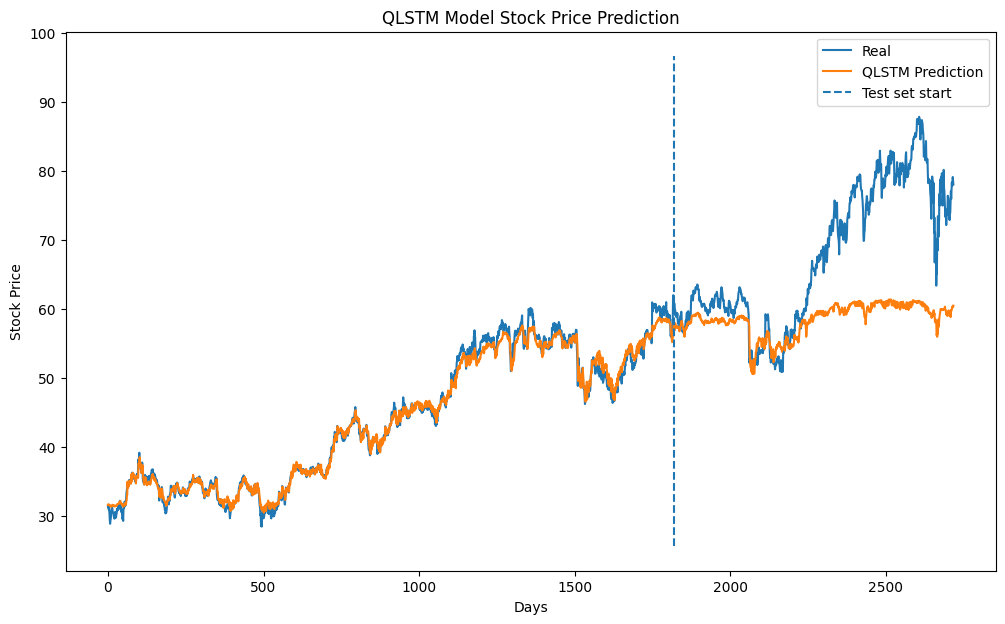

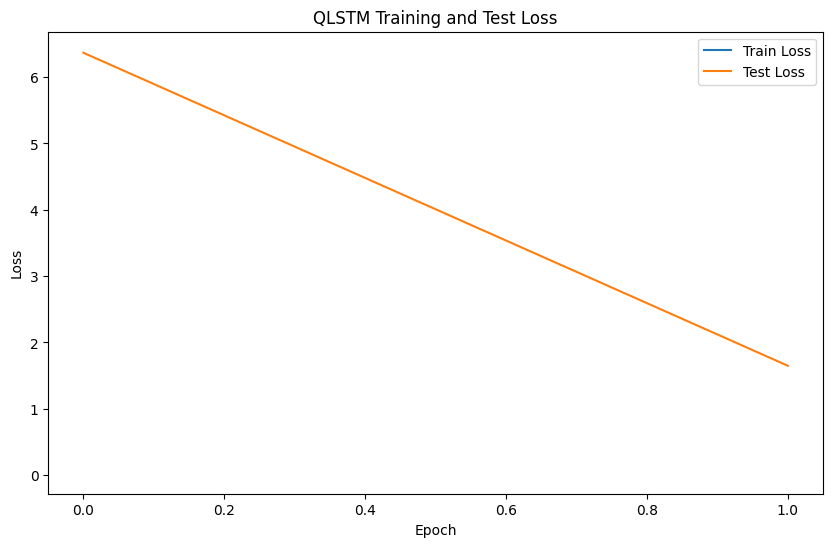

In [72]:
# Train the QLSTM model with all required parameters
qlstm_model, df_out_Q, qlstm_loss_train, qlstm_loss_test = train_qlstm_model(
    train_dataset, test_dataset, train_loader, test_loader,
    features, target, target_stdev, target_mean, size,
    df_train, df_test, batch_size
)